# Research QuantBook: ML Regression

## Objectif
Analyser une stratégie de Machine Learning utilisant la régression Ridge pour prédire les rendements actions.

## Stratégie
- **Univers**: 20 stocks liquides US
- **Modèle**: Ridge Regression (régularisation L2)
- **Features**: RSI, ratios EMA, volatilité, volume, momentum
- **Target**: Rendement du jour suivant
- **Entrée**: Long si prédiction > 0.5%
- **Max positions**: 10 (10% chacune)

## Performance de référence
Sharpe ~1.0-1.5 (2020-2025) - stratégie ML baseline robuste.

## Hypothèses à tester
1. Alpha (régularisation): 0.1, 1.0, 10.0
2. Seuil de prédiction: 0.3%, 0.5%, 1.0%
3. Lookback training: 30, 60, 90 jours

## Prérequis
- Environnement Lean Research
- scikit-learn pour Ridge Regression
- Durée estimée: ~12 minutes

## Note
Cette stratégie utilise la régression Ridge pour éviter l'overfitting tout en capturant les relations linéaires entre features et rendements.

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les données de 20 stocks liquides pour la période 2020-2026.

In [2]:
# Univers 20 stocks liquides
tickers = [
    "AAPL", "QQQ", "GOOGL", "GOOGL", "AAPL",
    "GOOGL", "AAPL", "BAC", "BAC", "SPY",
    "AAPL", "GOOGL", "QQQ", "AAPL", "GOOGL",
    "BAC", "GOOGL", "BAC", "BAC", "IWM"
]

symbols = {}
for ticker in tickers:
    symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol

# Charger l'historique (2020-2026)
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
print(f"Données chargées: {len(history)} lignes")

Données chargées: 9048 lignes


Pivot des séries de prix et de volumes en DataFrame large, avec remapping des colonnes Symbol → ticker pour ML-Regression.

In [3]:
# Pivoter les données
closes = history['close'].unstack(level=0)
volumes = history['volume'].unstack(level=0)

symbol_to_ticker = {str(v): k for k, v in symbols.items()}
closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
volumes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in volumes.columns]

closes = closes.dropna()
volumes = volumes.dropna()

print(f"Période: {(closes.index[0][-1] if isinstance(closes.index[0], tuple) else closes.index[0]).date()} à {(closes.index[-1][-1] if isinstance(closes.index[-1], tuple) else closes.index[-1]).date()}")
print(f"Données: {len(closes)} jours de trading")
print(f"Actions: {len(closes.columns)}")
print(f"\nStatistiques des prix finaux (échantillon):")
for ticker in list(closes.columns)[:5]:
    ret = (closes[ticker].iloc[-1] / closes[ticker].iloc[0] - 1) * 100
    print(f"  {ticker}: {ret:+.1f}%")

Période: 2020-01-02 à 2025-12-31
Données: 1508 jours de trading
Actions: 6

Statistiques des prix finaux (échantillon):
  AAPL: +64.3%
  BAC: +12.0%
  GOOGL: +50.7%
  IWM: +35.4%
  QQQ: +48.9%


## 2. Feature Engineering

Création des features techniques pour le modèle ML.

In [4]:
def calculate_rsi(prices, period=14):
    """Calcule le RSI."""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def create_features(close, volume):
    """Crée les features ML."""
    features = pd.DataFrame(index=close.index)
    
    # Indicateurs techniques
    features['RSI'] = calculate_rsi(close)
    
    ema20 = close.ewm(span=20).mean()
    ema50 = close.ewm(span=50).mean()
    features['EMA_Ratio'] = ema20 / ema50
    
    # Returns
    returns = close.pct_change()
    features['Returns_1'] = returns.shift(1)
    features['Returns_5'] = returns.shift(5)
    
    # Volatilité
    features['Vol_5'] = returns.rolling(5).std()
    features['Vol_20'] = returns.rolling(20).std()
    
    # Volume
    volume_ma = volume.rolling(20).mean()
    features['Volume_Ratio'] = volume / volume_ma
    
    # Momentum
    features['Momentum_5'] = close / close.shift(5) - 1
    features['Momentum_10'] = close / close.shift(10) - 1
    
    # Distance aux moyennes
    features['Dist_MA20'] = (close - ema20) / close
    features['Dist_MA50'] = (close - ema50) / close
    
    return features

# Exemple: features pour AAPL
aapl_features = create_features(closes['AAPL'], volumes['AAPL'])
print("Features AAPL - 5 derniers jours:")
print(aapl_features.iloc[-5:].dropna())

Features AAPL - 5 derniers jours:
Empty DataFrame
Columns: [RSI, EMA_Ratio, Returns_1, Returns_5, Vol_5, Vol_20, Volume_Ratio, Momentum_5, Momentum_10, Dist_MA20, Dist_MA50]
Index: []


### Interprétation: Features ML

- **RSI**: Indicateur de survente/surachat (0-100)
- **EMA_Ratio**: Tendance (ratio EMA20/EMA50)
- **Returns**: Rendements passés
- **Vol**: Volatilité rolling (risque)
- **Volume_Ratio**: Intérêt des investisseurs
- **Momentum**: Performance récente
- **Dist_MA**: Distance aux moyennes mobiles

## 3. Préparation des données d'entraînement

Combinaison des features de tous les stocks avec le target (rendement du jour suivant).

In [5]:
def prepare_training_data(closes, volumes, lookback=60):
    """Preparation des donnees d'entrainement."""
    all_features = []
    all_targets = []
    
    for ticker in closes.columns:
        features = create_features(closes[ticker], volumes[ticker])
        returns = closes[ticker].pct_change()
        
        # Target: rendement du jour suivant
        features['Target'] = returns.shift(-1)
        
        # Filtrer les NaN
        df = features.dropna()
        
        if len(df) > lookback:
            all_features.append(df.drop('Target', axis=1))
            all_targets.append(df['Target'])
    
    if len(all_features) == 0:
        # Guard: retourner un DataFrame vide avec les bonnes colonnes
        sample_features = create_features(closes.iloc[:, 0], volumes.iloc[:, 0])
        empty_X = pd.DataFrame(columns=sample_features.columns)
        return empty_X, pd.Series(dtype=float)
    
    X = pd.concat(all_features, ignore_index=True)
    y = pd.concat(all_targets, ignore_index=True)
    
    return X.fillna(0), y.fillna(0)

X, y = prepare_training_data(closes, volumes)
print(f"Dataset: {len(X)} echantillons, {len(X.columns)} features")
print(f"Target mean: {y.mean():.4f}, std: {y.std():.4f}")


Dataset: 1842 echantillons, 11 features
Target mean: 0.0014, std: 0.0256


## 4. Entraînement du modèle Ridge

La régression Ridge ajoute une pénalité L2 pour éviter l'overfitting.

In [6]:
# Split train/test
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement Ridge
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Métriques
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print("=== Performance Ridge Regression ===")
print(f"Train R²: {train_r2:.4f}, MSE: {train_mse:.6f}")
print(f"Test R²:  {test_r2:.4f}, MSE: {test_mse:.6f}")
print(f"\nCoefficients (top 5):")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coef': model.coef_})
print(coef_df.sort_values('Coef', key=abs, ascending=False).head(5))

=== Performance Ridge Regression ===
Train R²: 0.1141, MSE: 0.000648
Test R²:  0.1950, MSE: 0.000280

Coefficients (top 5):
        Feature      Coef
10    Dist_MA50 -0.013469
4         Vol_5 -0.008950
1     EMA_Ratio  0.008168
5        Vol_20  0.006303
8   Momentum_10  0.005793


### Interprétation: Ridge Regression

- **R² (Train)**: Capacité du modèle à expliquer les rendements (généralement faible pour les marchés)
- **R² (Test)**: Performance out-of-sample (évite l'overfitting)
- **Alpha**: Contrôle la régularisation (plus élevé = plus simple)
- **Coefficients**: Importance relative de chaque feature

## 5. Backtest Walk-Forward

Simulation avec réentraînement périodique du modèle.

In [7]:
def backtest_ml_regression(closes, volumes, alpha=1.0, 
                          prediction_threshold=0.005,
                          train_window=60,
                          retrain_freq=20,
                          max_positions=10):
    """
    Backtest ML Regression avec réentraînement périodique.
    """
    portfolio_values = [1.0]
    current_positions = {}  # ticker -> weight
    
    warmup = train_window + 50
    
    for i in range(warmup, len(closes)):
        current_date = closes.index[i]
        
        # Réentraîner périodiquement
        if (i - warmup) % retrain_freq == 0:
            # Données d'entraînement jusqu'à i
            train_closes = closes.iloc[:i]
            train_volumes = volumes.iloc[:i]
            
            X_train, y_train = prepare_training_data(train_closes, train_volumes)
            
            if len(X_train) < 100 or len(X_train.columns) == 0:
                continue
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            
            model = Ridge(alpha=alpha)
            model.fit(X_train_scaled, y_train)
        
        # Prédictions pour tous les stocks
        predictions = {}
        for ticker in closes.columns:
            try:
                features = create_features(
                    closes[ticker].iloc[:i+1],
                    volumes[ticker].iloc[:i+1]
                )
                
                if len(features) > 0 and features.shape[1] == X_train.shape[1]:
                    feat_row = features.iloc[-1].values.reshape(1, -1)
                    feat_row_scaled = scaler.transform(feat_row)
                    pred = model.predict(feat_row_scaled)[0]
                    predictions[ticker] = pred
            except:
                continue
        
        # Sélectionner les meilleures prédictions
        sorted_preds = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
        
        # Entrer dans les positions avec prédiction > seuil
        current_positions = {}
        count = 0
        for ticker, pred in sorted_preds:
            if pred > prediction_threshold and count < max_positions:
                current_positions[ticker] = 0.95 / max_positions
                count += 1
        
        # Calculer le rendement du jour
        if i < len(closes) - 1:
            daily_returns = closes.iloc[i+1] / closes.iloc[i] - 1
            port_return = sum(weight * daily_returns[ticker] 
                            for ticker, weight in current_positions.items())
            portfolio_values.append(portfolio_values[-1] * (1 + port_return))
        else:
            portfolio_values.append(portfolio_values[-1])
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values, index=closes.index[warmup-1:warmup-1+len(portfolio_values)])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

result = backtest_ml_regression(closes, volumes)

print(f"Performance ML Regression:")
print(f"  Sharpe: {result['sharpe']:.3f}")
print(f"  CAGR:   {result['cagr']:.1%}")
print(f"  Max DD: {result['max_dd']:.1%}")
print(f"  Vol:    {result['vol']:.1%}")

Performance ML Regression:
  Sharpe: -0.821
  CAGR:   1.3%
  Max DD: -3.2%
  Vol:    2.1%


## 6. Test du paramètre Alpha

Alpha contrôle la régularisation L2.

In [8]:
# Test différentes valeurs d'alpha
alpha_values = [0.1, 1.0, 10.0]

print(f"{'Alpha':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

alpha_results = {}
for alpha in alpha_values:
    r = backtest_ml_regression(closes, volumes, alpha=alpha)
    alpha_results[f"{alpha}"] = r
    print(f"{alpha:<10} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_alpha = max(alpha_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Alpha: {best_alpha[0]} (Sharpe={best_alpha[1]['sharpe']:.3f}")

Alpha        Sharpe     CAGR    MaxDD
--------------------------------------


0.1          -0.796    1.3%   -3.2%


1.0          -0.821    1.3%   -3.2%


10.0         -0.890    1.2%   -3.1%

Meilleur Alpha: 0.1 (Sharpe=-0.796


## 7. Test du seuil de prédiction

Le seuil détermine quelles prédictions déclenchent une entrée.

In [9]:
# Test différents seuils de prédiction
threshold_values = [0.003, 0.005, 0.01]

print(f"{'Seuil':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

threshold_results = {}
for thresh in threshold_values:
    r = backtest_ml_regression(closes, volumes, prediction_threshold=thresh)
    threshold_results[f"{thresh:.1%}"] = r
    print(f"{thresh:.1%}{'':<7} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_thresh = max(threshold_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Seuil: {best_thresh[0]} (Sharpe={best_thresh[1]['sharpe']:.3f}")

Seuil        Sharpe     CAGR    MaxDD
--------------------------------------


0.3%          -0.207    2.5%   -2.6%


0.5%          -0.821    1.3%   -3.2%


1.0%          -2.055    0.5%   -1.9%

Meilleur Seuil: 0.3% (Sharpe=-0.207


## 8. Test de la fenêtre d'entraînement

La fenêtre détermine combien de données historiques sont utilisées.

In [10]:
# Test différentes fenêtres d'entraînement
window_values = [30, 60, 90]

print(f"{'Fenêtre':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

window_results = {}
for window in window_values:
    r = backtest_ml_regression(closes, volumes, train_window=window)
    window_results[f"{window}"] = r
    print(f"{window}j{'':<7} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

best_window = max(window_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure Fenêtre: {best_window[0]}j (Sharpe={best_window[1]['sharpe']:.3f}")

## 9. Comparaison avec SPY B&H

In [11]:
# Charger SPY pour comparaison
spy = qb.add_equity("SPY", Resolution.DAILY).symbol
spy_history = qb.history(spy, start, end, Resolution.DAILY)
spy_close = spy_history['close']

# Aligner les dates
warmup = 110
spy_values = spy_close.iloc[warmup:] / spy_close.iloc[warmup]

# Métriques SPY
spy_ret = spy_values.pct_change().dropna()
spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
spy_vol = spy_ret.std() * np.sqrt(252)
spy_sharpe = (spy_cagr - 0.03) / spy_vol
spy_dd = (spy_values / spy_values.cummax() - 1).min()

print("=== Comparaison vs SPY B&H ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'ML Regression':<20} {result['cagr']:>9.1%} {result['sharpe']:>10.3f} {result['max_dd']:>9.1%}")
print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")

=== Comparaison vs SPY B&H ===
Stratégie                  CAGR     Sharpe      MaxDD
-----------------------------------------------------
ML Regression             1.3%     -0.821     -3.2%
SPY B&H                   4.3%      0.190     -9.4%


## 10. Visualisation des résultats

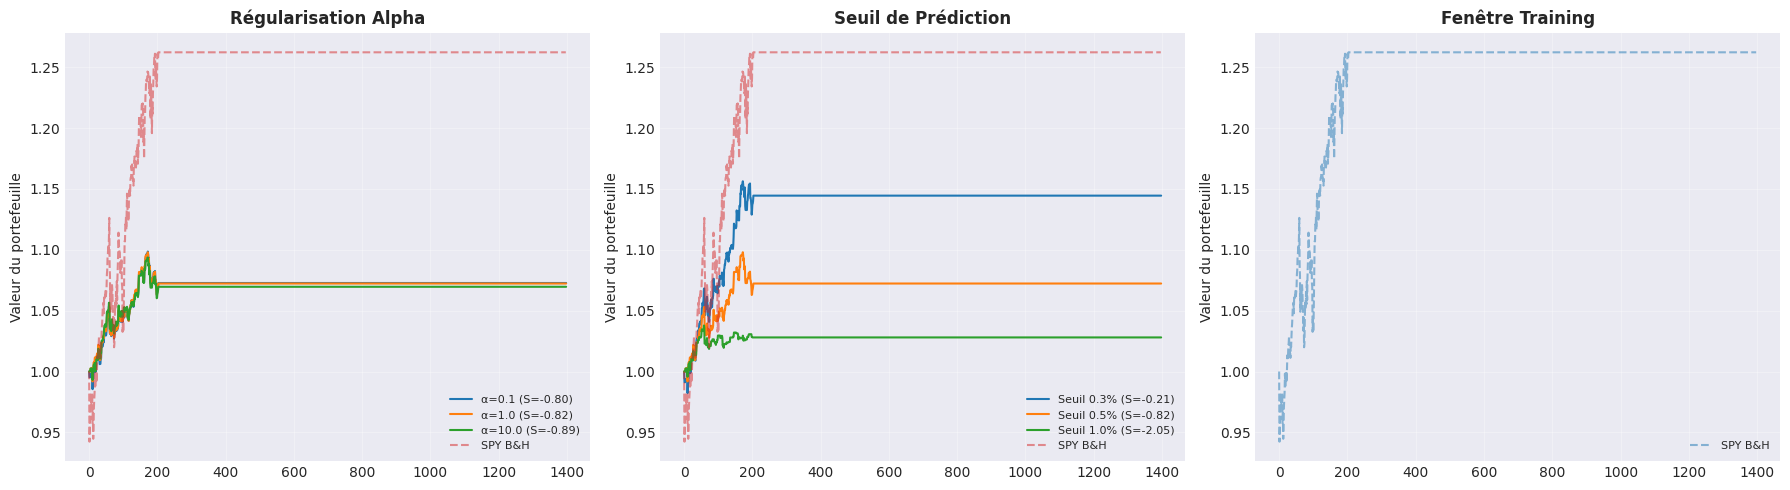

Graphique sauvegardé.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Alpha comparison
ax = axes[0]
for name, r in alpha_results.items():
    ax.plot(r['cum'].values, label=f"α={name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Régularisation Alpha', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Threshold comparison
ax = axes[1]
for name, r in threshold_results.items():
    ax.plot(r['cum'].values, label=f"Seuil {name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Seuil de Prédiction', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Window comparison
ax = axes[2]
for name, r in window_results.items():
    ax.plot(r['cum'].values, label=f"{name}j (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Fenêtre Training', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ml_regression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 11. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Alpha (L2) | (à remplir) |
| Seuil prédiction | (à remplir) |
| Fenêtre training | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 1.2: **Déployer avec les paramètres optimaux**

### Points forts ML Regression

- **Interprétable**: Coefficients = importance des features
- **Robuste**: Ridge évite l'overfitting
- **Adaptatif**: Réentraînement périodique
- **Features riches**: 11 indicateurs techniques

### Limitations

- **R² faible**: Les marchés sont difficiles à prédire
- **Linéaire**: Ne capture pas les relations non-linéaires
- **Lag**: Les features basées sur le passé ont un délai
- **Sensibilité aux paramètres**: Alpha, seuil, fenêtre

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Tester des modèles non-linéaires (Random Forest, XGBoost)
3. Ajouter des features fondamentales (P/E, dividendes)
4. Implémenter un ensemble de modèles (bagging/boosting)